# WEAVIATE

## Document Parsing 

In [4]:
file = "/home/quang/My_Project/Paraline/paraline/document/Huong-dan-doc-va-phan-tich-BCTC-NHANH.pdf"
print(file)

/home/quang/My_Project/Paraline/paraline/document/Huong-dan-doc-va-phan-tich-BCTC-NHANH.pdf


In [5]:
import os
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import (
    PdfPipelineOptions,
    PictureDescriptionApiOptions
)
from docling.document_converter import DocumentConverter, PdfFormatOption
from docling_core.types.doc.document import ImageRefMode

def convert_with_image_annotation(input_doc_path):
    # Thay đổi API key cho Together AI hoặc provider khác
    api_key = os.environ.get("TOGETHER_API_KEY")  # hoặc API_KEY tương ứng
    model = "google/gemma-3n-E4B-it"
    
    # Cấu hình cho Llama Vision model
    picture_desc_api_option = PictureDescriptionApiOptions(
        # URL cho Together AI (hoặc provider khác hỗ trợ Llama)
        url="https://api.together.xyz/v1/chat/completions",
        prompt="Describe this image in sentences in a single paragraph",
        params=dict(
            model=model,
            max_tokens=512,  # Giới hạn tokens cho response
            temperature=0.1,  # Giảm temperature để có response ổn định hơn
            ),
        headers={
            "Authorization": "Bearer " + api_key,
            "Content-Type": "application/json",
        },
        timeout=120,  # Tăng timeout vì Llama model có thể chậm hơn
    )

    pipeline_options = PdfPipelineOptions(
        do_picture_description=True,
        picture_description_options=picture_desc_api_option,
        enable_remote_services=True,
        generate_picture_images=True,
        images_scale=2,
    )

    converter = DocumentConverter(
        format_options={InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)}
    )
    
    conv_res = converter.convert(source=input_doc_path)
    return conv_res

2025-09-24 17:06:52,251 - INFO - detected formats: [<InputFormat.PDF: 'pdf'>]
2025-09-24 17:06:52,288 - INFO - Going to convert document batch...
2025-09-24 17:06:52,289 - INFO - Initializing pipeline for StandardPdfPipeline with options hash 68e059f3e75bb40d4b4d82a1df76f3d7
2025-09-24 17:06:52,295 - INFO - Loading plugin 'docling_defaults'
2025-09-24 17:06:52,296 - INFO - Registered picture descriptions: ['vlm', 'api']
2025-09-24 17:06:52,303 - INFO - Loading plugin 'docling_defaults'
2025-09-24 17:06:52,306 - INFO - Registered ocr engines: ['easyocr', 'ocrmac', 'rapidocr', 'tesserocr', 'tesseract']
2025-09-24 17:06:52,523 - INFO - Accelerator device: 'cuda:0'
2025-09-24 17:06:54,128 - INFO - Accelerator device: 'cuda:0'
2025-09-24 17:06:55,910 - INFO - Accelerator device: 'cuda:0'
2025-09-24 17:06:56,493 - INFO - Processing document Huong-dan-doc-va-phan-tich-BCTC-NHANH.pdf
2025-09-24 17:09:06,718 - INFO - Finished converting document Huong-dan-doc-va-phan-tich-BCTC-NHANH.pdf in 134.

schema_name='DoclingDocument' version='1.7.0' name='Huong-dan-doc-va-phan-tich-BCTC-NHANH' origin=DocumentOrigin(mimetype='application/pdf', binary_hash=5756462280797216791, filename='Huong-dan-doc-va-phan-tich-BCTC-NHANH.pdf', uri=None) furniture=GroupItem(self_ref='#/furniture', parent=None, children=[], content_layer=<ContentLayer.FURNITURE: 'furniture'>, name='_root_', label=<GroupLabel.UNSPECIFIED: 'unspecified'>) body=GroupItem(self_ref='#/body', parent=None, children=[RefItem(cref='#/pictures/0'), RefItem(cref='#/texts/0'), RefItem(cref='#/texts/1'), RefItem(cref='#/pictures/1'), RefItem(cref='#/texts/25'), RefItem(cref='#/texts/26'), RefItem(cref='#/texts/27'), RefItem(cref='#/tables/0'), RefItem(cref='#/pictures/2'), RefItem(cref='#/texts/28'), RefItem(cref='#/texts/29'), RefItem(cref='#/pictures/3'), RefItem(cref='#/tables/1'), RefItem(cref='#/texts/30'), RefItem(cref='#/texts/31'), RefItem(cref='#/pictures/4'), RefItem(cref='#/texts/32'), RefItem(cref='#/texts/33'), RefItem(
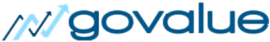
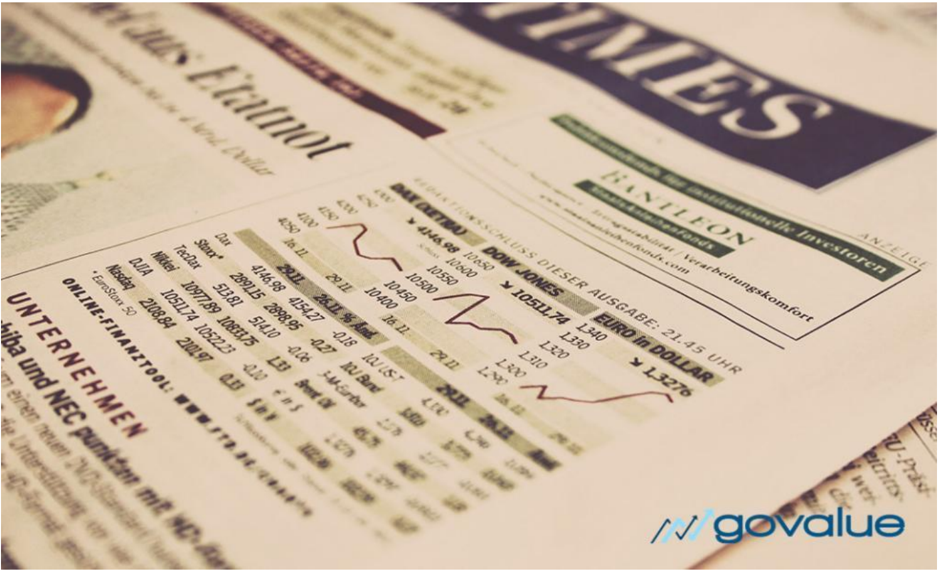
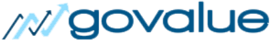
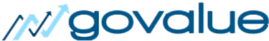
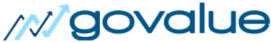
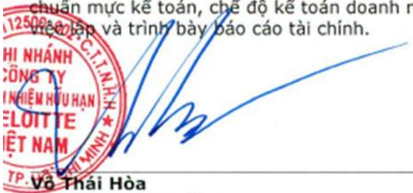
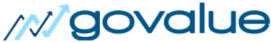
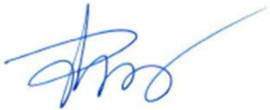
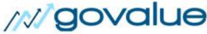
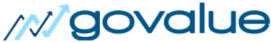
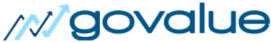
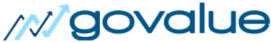
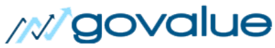
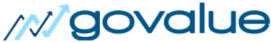
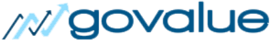
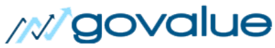
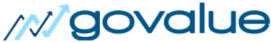
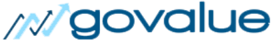
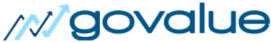
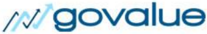
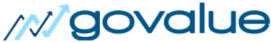
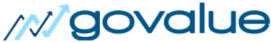
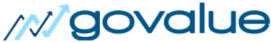
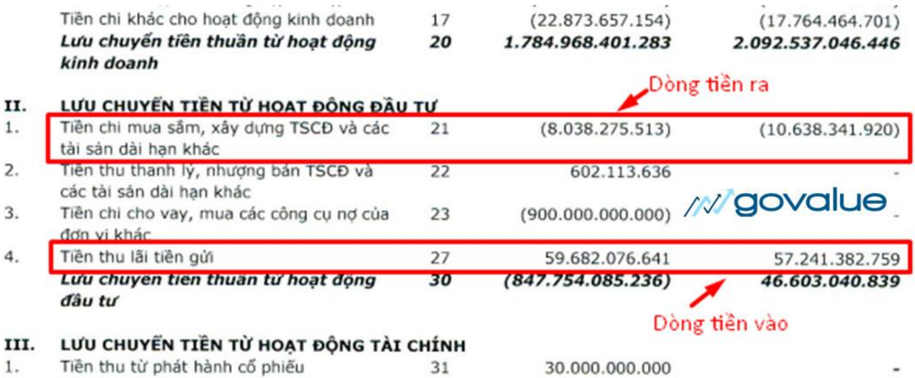
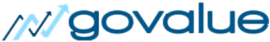
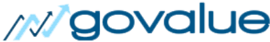
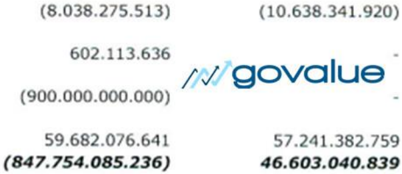
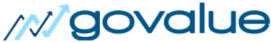
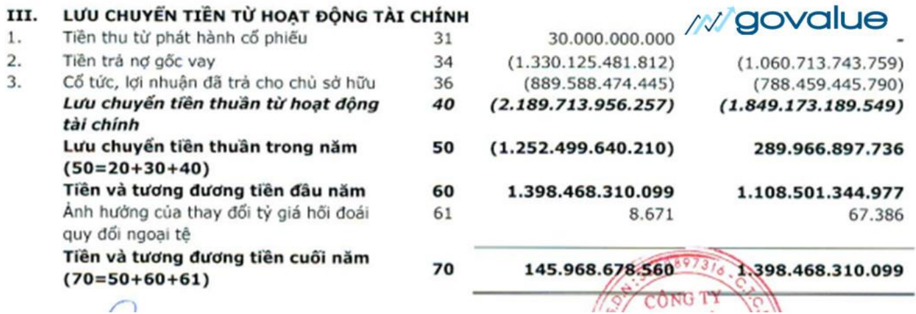
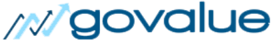
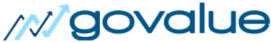
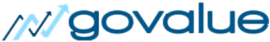
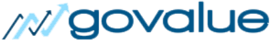
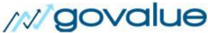
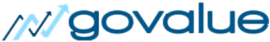
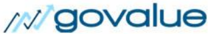
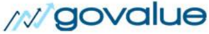
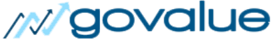
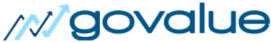
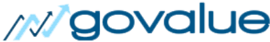
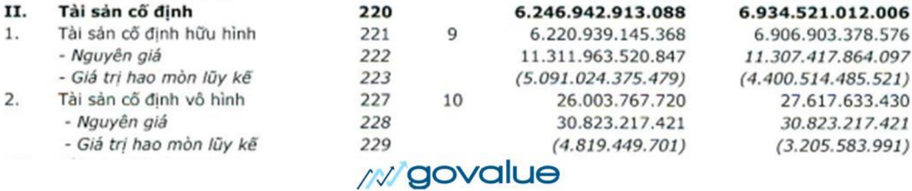
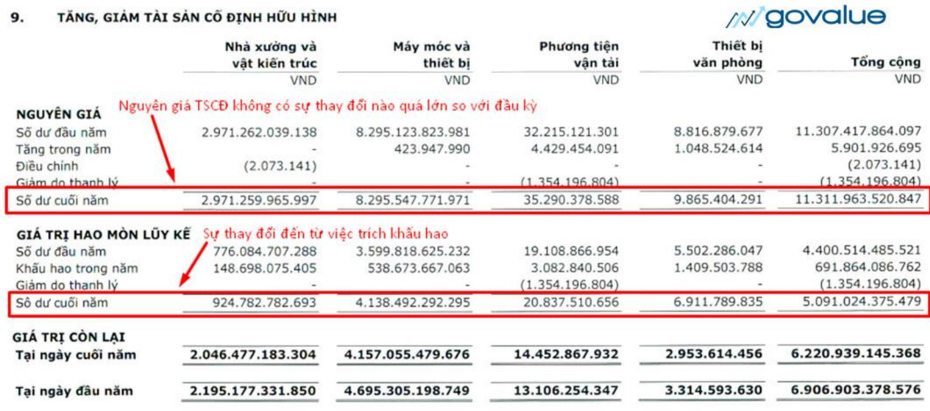
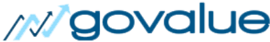
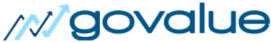
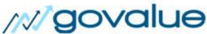
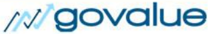
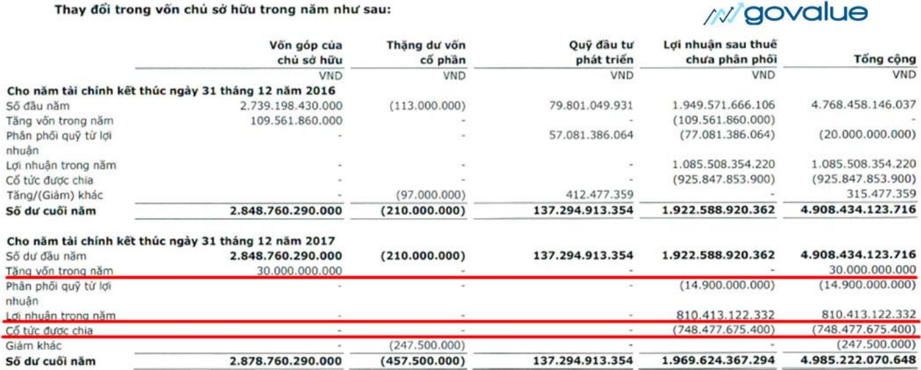
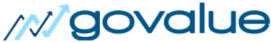
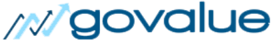
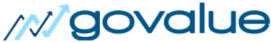
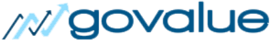
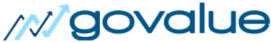
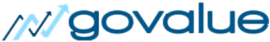
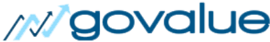
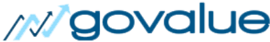
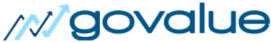
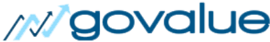
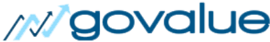
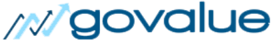
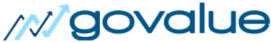
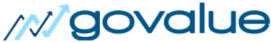
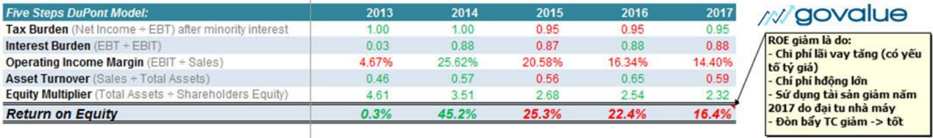
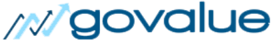
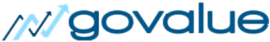
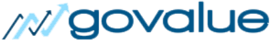
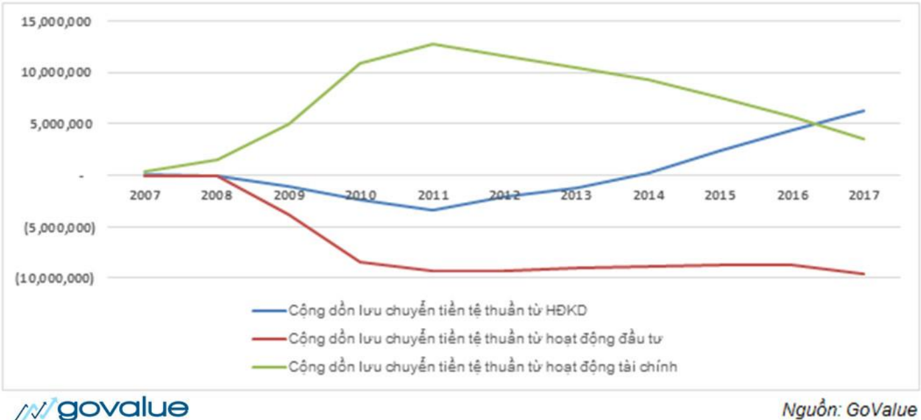
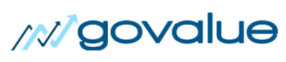

In [6]:
result = convert_with_image_annotation(file)
document = result.document
print(document)

In [7]:
document = result.document.export_to_markdown(mark_annotations = True, include_annotations=True)

In [8]:
print(type(document))

<class 'str'>


## Chunking 

In [9]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain.schema import Document
text_splitter = RecursiveCharacterTextSplitter(chunk_size=100, chunk_overlap=20)
chunks = text_splitter.split_text(document)
docs = [Document(page_content=chunk) for chunk in chunks]

## Embedding 

In [10]:
from langchain_openai import OpenAIEmbeddings
from dotenv import load_dotenv
import os
load_dotenv()

class OpenAIEmbedding:
    def __init__(self, model: str = "text-embedding-3-small", chunk_size: int = 1):
        self.API_KEY = os.getenv("OPENAI_API_KEY")
        self.model = model
        self.chunk_size = chunk_size
        self.embeddings = OpenAIEmbeddings(model=self.model, chunk_size=self.chunk_size,api_key=self.API_KEY)

    def embed_documents(self, texts):
        return self.embeddings.embed_documents(texts)

    def embed_query(self, text):
        return self.embeddings.embed_query(text)

In [11]:
OpenAIEmbedding = OpenAIEmbedding(model="text-embedding-3-small", chunk_size=1)

## Define vectorDB

In [12]:
import weaviate
from langchain_weaviate.vectorstores import WeaviateVectorStore

In [13]:
weaviate_client = weaviate.connect_to_local()


2025-09-24 17:09:07,689 - INFO - HTTP Request: GET http://localhost:8080/v1/.well-known/openid-configuration "HTTP/1.1 404 Not Found"
2025-09-24 17:09:07,698 - INFO - HTTP Request: GET http://localhost:8080/v1/meta "HTTP/1.1 200 OK"
2025-09-24 17:09:13,824 - INFO - HTTP Request: GET https://pypi.org/pypi/weaviate-client/json "HTTP/1.1 200 OK"
/home/quang/miniconda3/envs/paraline/lib/python3.10/site-packages/weaviate/warnings.py:302: ResourceWarning: Con004: The connection to Weaviate was not closed properly. This can lead to memory leaks.
            Please make sure to close the connection using `client.close()`.
  warnings.warn(
/tmp/ipykernel_4598/1364657021.py:1: ResourceWarning: unclosed <socket.socket fd=63, family=AddressFamily.AF_INET, type=SocketKind.SOCK_STREAM, proto=6, laddr=('127.0.0.1', 37378), raddr=('127.0.0.1', 8080)>
  weaviate_client = weaviate.connect_to_local()


In [31]:
store = WeaviateVectorStore(
    client=weaviate_client,
    index_name="LangChain_21b78bd3a3524cb9a56bfff2e88e69b0",
    text_key="text",
    embedding=OpenAIEmbedding
)

2025-09-24 17:38:33,596 - INFO - HTTP Request: GET http://localhost:8080/v1/schema/LangChain_21b78bd3a3524cb9a56bfff2e88e69b0 "HTTP/1.1 200 OK"
2025-09-24 17:38:33,599 - INFO - HTTP Request: GET http://localhost:8080/v1/schema/LangChain_21b78bd3a3524cb9a56bfff2e88e69b0 "HTTP/1.1 200 OK"


## Insert VectorDB

In [ ]:
from langchain.schema import Document
# Chuyển chunks (list[str]) thành list[Document]
docs = [Document(page_content=chunk) for chunk in chunks]
db = store.from_documents(docs, OpenAIEmbedding, client=weaviate_client)

2025-09-24 17:09:13,909 - INFO - HTTP Request: GET http://localhost:8080/v1/schema/LangChain_334d4629e4994d7c8191fd722313e9d8 "HTTP/1.1 404 Not Found"
2025-09-24 17:09:13,914 - INFO - HTTP Request: POST http://localhost:8080/v1/schema "HTTP/1.1 200 OK"
2025-09-24 17:09:13,916 - INFO - HTTP Request: GET http://localhost:8080/v1/schema/LangChain_334d4629e4994d7c8191fd722313e9d8 "HTTP/1.1 200 OK"
2025-09-24 17:09:19,367 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-09-24 17:09:23,639 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-09-24 17:09:24,179 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-09-24 17:09:24,691 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-09-24 17:09:25,100 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2025-09-24 17:09:25,818 - INFO - HTTP Request: POST https://api.open

KeyboardInterrupt: 

## Search 

In [ ]:
query = "Báo cáo lưu chuyển tiền tệ đã được trình bày thành 3 phần tương ứng với 3 dòng tiền: Dòng tiền từ hoạt động kinh doanh, Dòng tiền từ hoạt động đầu tư, và Dòng tiền từ hoạt động tài chính."
docs = store.similarity_search(query)
print(docs)

for i, doc in enumerate(docs):
    print(f"\nDocument {i + 1}:")
    print(doc.page_content[:100])

2025-09-24 17:38:39,005 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


[Document(metadata={}, page_content='Báo cáo lưu chuyển tiền tệ đã được trình bày thành 3 phần tương ứng với 3 dòng tiền: Dòng tiền từ'), Document(metadata={}, page_content='tiền: Dòng tiền từ hoạt động kinh doanh, Dòng tiền từ hoạt động đầu tư, và Dòng tiền từ hoạt động'), Document(metadata={}, page_content='Như vậy, báo cáo lưu chuyển tiền tệ ghi lại dòng tiền vận động trong doanh nghiệp như thế nào?'), Document(metadata={}, page_content='## Dòng tiền vào, dòng tiền ra được thể hiện như thế nào trên Báo cáo lưu chuyển tiền tệ?')]

Document 1:
Báo cáo lưu chuyển tiền tệ đã được trình bày thành 3 phần tương ứng với 3 dòng tiền: Dòng tiền từ

Document 2:
tiền: Dòng tiền từ hoạt động kinh doanh, Dòng tiền từ hoạt động đầu tư, và Dòng tiền từ hoạt động

Document 3:
Như vậy, báo cáo lưu chuyển tiền tệ ghi lại dòng tiền vận động trong doanh nghiệp như thế nào?

Document 4:
## Dòng tiền vào, dòng tiền ra được thể hiện như thế nào trên Báo cáo lưu chuyển tiền tệ?


## Near Image

In [ ]:
import weaviate
from weaviate.classes.config import Property, DataType

client = weaviate.connect_to_local()

# Tạo collection mới
client.collections.create(
    name="FashionItem",
    description="An item with image",
    vectorizer_config="img2vec-neural",   
    properties=[
        Property(
            name="image",
            data_type=DataType.BLOB,
            description="Image of the item"
        ),
        Property(
            name="label",
            data_type=DataType.TEXT,
            description="Label / name of item"
        )
    ],
)


/home/quang/miniconda3/envs/paraline/lib/python3.10/site-packages/weaviate/warnings.py:196: DeprecationWarning: Dep024: You are using the `vectorizer_config` argument in `collection.config.create()`, which is deprecated.
            Use the `vector_config` argument instead.
            
  warnings.warn(


KeyError: 'vectorizerConfig'

In [ ]:
import base64
import os
import uuid

def encode_image_to_base64(image_path):
    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

def add_image_object(client, class_name, image_path, metadata: dict):
    b64 = encode_image_to_base64(image_path)
    properties = metadata.copy()
    properties["image"] = b64
    client.data_object.create(properties, class_name, str(uuid.uuid4()))

# ví dụ
add_image_object(client, "FashionItem", "path/to/image1.jpg", {"label": "shirt"})
add_image_object(client, "FashionItem", "path/to/image2.jpg", {"label": "hat"})

In [ ]:
# Neu co nhieu anh thi su dung batch 
client.batch.configure(batch_size=50, dynamic=True)
for img_path in list_of_images:
    add_image_object(client, "FashionItem", img_path, {"label": ...})

In [ ]:
result = (
    client.query
    .get("FashionItem", ["label", "image"])
    .with_near_image({"image": base64_query_image})
    .with_limit(5)
    .do()
)

print(result)